# Configs

In [1]:
import random


random.seed(27)

splitPartCount = 5
splitSeed = 27
hoursPerWindow = 1

# Load data

In [2]:
from utils.prepare_data import getMonitoredPatients
from pandas import Timedelta


patients = getMonitoredPatients()
patients.removePatientAkiEarly(Timedelta(hours=12))

print("Total ", len(patients))
print("AKI ", sum([1 for p in patients if p.akdPositive]))
print("Ratio ", sum([1 for p in patients if p.akdPositive]) / len(patients))

Total  1124
AKI  392
Ratio  0.3487544483985765


# Model

In [3]:
import tabpfn
import torch
import torch.nn as nn
import math


class PositionalEncoding(nn.Module):
    def __init__(self, model_dim, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, model_dim)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, model_dim, 2).float() * (-math.log(10000.0) / model_dim)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: [batch_size, seq_len, model_dim]
        x = x + self.pe[: x.size(1)]
        return x


class TimeSeriesTransformerWithMLP(nn.Module):
    def __init__(
        self,
        n_staticFeat,
        n_timeFeat,
        model_dim,
        transformer_layers=4,
        nhead=8,
        hidden_dim=128,
        use_cls=True,
    ):
        super().__init__()
        self.use_cls = use_cls
        self.model_dim = model_dim

        # Project input features through an MLP
        self.mlp = nn.Sequential(
            nn.Linear(n_timeFeat, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, model_dim)
        )

        # Positional encoding
        self.pos_encoder = PositionalEncoding(model_dim)

        # [CLS] token
        if use_cls:
            self.cls_token = nn.Parameter(torch.zeros(1, 1, model_dim))
            nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=nhead, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer, num_layers=transformer_layers
        )

        # static features projection
        self.static_proj = nn.Linear(n_staticFeat, model_dim)
        
        # connect static and time features
        self.merge = nn.Linear(model_dim + model_dim, model_dim)

    def forward(self, staticX, timeX):
        # Apply MLP: [batch, n_time, model_dim]
        x = self.mlp(timeX)

        # Optionally prepend CLS token
        if self.use_cls:
            batch_size = x.size(0)
            cls = self.cls_token.expand(batch_size, -1, -1)  # [batch, 1, model_dim]
            x = torch.cat([cls, x], dim=1)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Transformer
        x = self.transformer(x)  # [batch, seq_len(+1), model_dim]

        # Extract CLS token embedding or pool
        if self.use_cls:
            cls_embedding = x[:, 0, :]  # [batch, model_dim]
        else:
            cls_embedding = x.mean(dim=1)  # Average pooling
            
        # Project static features
        static_embedding = self.static_proj(staticX)
        # Merge static and time features
        merged_embedding = torch.cat((cls_embedding, static_embedding), dim=1)
        
        out = self.merge(merged_embedding)  # [batch, model_dim]

        return out

# Train and eval

## Functions

In [4]:
from torch.optim.lr_scheduler import ReduceLROnPlateau


def infer(transformer, tabpfnModel: tabpfn.TabPFNClassifier, device, dataLoader):
    transformer.to(device)
    transformer.eval()

    tabpfnModel.device = device

    predProbas = []
    actuals = []

    with torch.no_grad():
        for batch in dataLoader:
            static, timeSeries, labels = batch
            static = static.to(device)
            timeSeries = timeSeries.to(device)
            labels = labels.to(device)

            embedding = transformer(static, timeSeries)
            proba = tabpfnModel.predict_proba(embedding)

            predProbas.append(proba[:, 1].unsqueeze(1))  # type: ignore # Get probability of positive class
            actuals.append(labels)

    return torch.cat(predProbas), torch.cat(actuals)


def train(
    transformer,
    tabpfnModel: tabpfn.TabPFNClassifier,
    device,
    trainLoader,
    valLoader,
    criterion,
    optimizer,
    epochs=100,
    earlyStopping=10,
):
    transformer.to(device)

    tabpfnModel.device = device

    # load dummy context to tabpfn
    n_sample = len(trainLoader.dataset)
    contextX = torch.rand(n_sample, transformer.model_dim).to(device)
    contextY = []
    for batch in trainLoader:
        _, _, labels = batch
        labels = labels.to("cpu")  # TabPFN expects labels on CPU
        contextY.append(labels)
    contextY = torch.cat(contextY, dim=0)
    contextY = contextY.view(-1)  # unravel the labels
    tabpfnModel.fit(contextX, contextY)

    optimScheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=4)

    # early stopping
    bestValLoss = float("inf")
    bestModelState = None
    bestContext = (None, None)
    patience = 0

    trainLosses = []
    valLosses = []

    for epoch in range(epochs):
        transformer.train()
        trainLoss = 0

        nwContextX = []
        nwContextY = []

        for batch in trainLoader:
            static, timeSeries, labels = batch
            static = static.to(device)
            timeSeries = timeSeries.to(device)
            labels = labels.to(device)

            embedding = transformer(static, timeSeries)
            nwContextX.append(embedding.detach())
            nwContextY.append(labels.detach().cpu())  # TabPFN expects labels on CPU
            proba = tabpfnModel.predict_proba(embedding)[:, 1]  # Get probability of positive class
            proba = proba.unsqueeze(1)

            loss = criterion(proba, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            trainLoss += loss.item() * len(labels)

        trainLoss /= len(trainLoader.dataset)
        trainLosses.append(trainLoss)

        # validation
        valPred, valActual = infer(transformer, tabpfnModel, device, valLoader)
        valLoss = criterion(valPred, valActual)
        valLosses.append(valLoss.item())

        optimScheduler.step(valLoss)

        if valLoss < bestValLoss:
            bestValLoss = valLoss
            bestModelState = transformer.state_dict()
            bestContext = contextX, contextY
            patience = 0
        else:
            patience += 1

        # update TabPFN context
        contextX = torch.cat(nwContextX, dim=0)
        contextY = torch.cat(nwContextY, dim=0)
        tabpfnModel.fit(contextX, contextY)

        print(
            f"Epoch {epoch+1}/{epochs} Train Loss: {trainLoss:.4f} Val Loss: {valLoss:.4f}"
        )

        if patience > earlyStopping:
            break

    transformer.load_state_dict(bestModelState)
    tabpfnModel.fit(bestContext[0], bestContext[1])  # restore best context
    return transformer, tabpfnModel, trainLosses, valLosses

## Cross-val

In [5]:
%%capture

import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (  # noqa: E402
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    auc,
)
from utils.class_voter import combineProbas  # noqa: E402
from utils.prepare_data import (  # noqa: E402
    DeepLearningDataPreparer,
    trainValTestPatients,
)
import numpy as np  # noqa: E402


# warnings.filterwarnings("ignore", category=UserWarning)
# warnings.filterwarnings("ignore", category=FutureWarning)


accuracy_score_list = []
precision_score_list = []
recall_score_list = []
auc_score_list = []
specificity_score_list = []
sensitivity_score_list = []
auc_pr_list = []

train_loss_list = []
val_loss_list = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batchSize = 64

for i, (trainValGenerator, testPatients) in enumerate(
    trainValTestPatients(patients, splitSeed)
):
    models = []
    probas = []
    for ii, (trainPatients, valPatients) in enumerate(trainValGenerator):
        preparer = DeepLearningDataPreparer(
            hoursPerWindows=hoursPerWindow,
            fromHour=0,
            toHour=12,
        )

        (
            (npTrainX, staticTrainX, trainY),
            (npValX, staticValX, valY),
            (npTestX, staticTestX, testY),
        ) = preparer.trainValTest(trainPatients, valPatients, testPatients)

        # create data loader
        trainLoader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(staticTrainX).float(),
                torch.tensor(npTrainX).float(),
                torch.tensor(trainY).unsqueeze(1).float(),
            ),
            batch_size=batchSize,
            pin_memory=True,
            shuffle=True,
        )
        valLoader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(staticValX).float(),
                torch.tensor(npValX).float(),
                torch.tensor(valY).unsqueeze(1).float(),
            ),
            batch_size=batchSize,
            pin_memory=True,
            shuffle=False,
        )
        testLoader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                torch.tensor(staticTestX).float(),
                torch.tensor(npTestX).float(),
                torch.tensor(testY).unsqueeze(1).float(),
            ),
            batch_size=batchSize,
            pin_memory=True,
            shuffle=False,
        )

        n_staticFeat = staticTrainX.shape[1]
        n_timeFeat = npTrainX.shape[2]

        transformer = TimeSeriesTransformerWithMLP(
            n_staticFeat=n_staticFeat,
            n_timeFeat=n_timeFeat,
            model_dim=96,
        )

        criterion = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(transformer.parameters(), lr=0.0005)

        tabpfnModel = tabpfn.TabPFNClassifier(
            device=str(device),
            no_grad=False,
            no_preprocess_mode=True,
            batch_size_inference=batchSize,
        )

        transformer, tabpfnModel, trainLosses, valLosses = train(
            transformer,
            tabpfnModel,
            device,
            trainLoader,
            valLoader,
            criterion,
            optimizer,
            epochs=50,
            earlyStopping=10,
        )

        # models.append(model)
        train_loss_list.append(trainLosses)
        val_loss_list.append(valLosses)

        predProbas, _ = infer(transformer, tabpfnModel, device, testLoader)
        probas.append(predProbas.detach().cpu().numpy())
        torch.save(transformer.state_dict(), f"result/transformer_tabpfn_model/{i}_{ii}.pt")

    # calculate final probas, auc, accuracy, precision, recal
    finalYProbas = np.apply_along_axis(combineProbas, 0, np.array(probas))
    finalYPred = np.where(finalYProbas > 0.5, 1, 0)
    tn, fp, fn, tp = confusion_matrix(testY, finalYPred).ravel()
    precision_vals, recall_vals, _ = precision_recall_curve(testY, finalYProbas)

    accuracy_score_list.append(accuracy_score(testY, finalYPred))
    specificity_score_list.append(tn / (tn + fp))
    precision_score_list.append(precision_score(testY, finalYPred))
    recall_score_list.append(recall_score(testY, finalYPred))
    auc_score_list.append(roc_auc_score(testY, finalYProbas))
    auc_pr_list.append(auc(recall_vals, precision_vals))

In [6]:
print(f"AUC: {np.mean(auc_score_list)} +- {np.std(auc_score_list)}", auc_score_list)
print(f"Accuracy: {np.mean(accuracy_score_list)} +- {np.std(accuracy_score_list)}", accuracy_score_list)
print(f"Specificity: {np.mean(specificity_score_list)} +- {np.std(specificity_score_list)}", specificity_score_list)
print(f"Precision: {np.mean(precision_score_list)} +- {np.std(precision_score_list)}", precision_score_list)
print(f"Recall: {np.mean(recall_score_list)} +- {np.std(recall_score_list)}", recall_score_list)
print(f"AUC PR: {np.mean(auc_pr_list)} +- {np.std(auc_pr_list)}", auc_pr_list)

AUC: 0.7578525631573763 +- 0.045230752776680865 [np.float64(0.6691958834815979), np.float64(0.775161346589918), np.float64(0.7953875498526096), np.float64(0.7814288191434021), np.float64(0.7680892167193537)]
Accuracy: 0.6832857142857144 +- 0.017433428068229388 [0.6711111111111111, 0.7066666666666667, 0.6577777777777778, 0.6844444444444444, 0.6964285714285714]
Specificity: 0.9849501444413381 +- 0.017544301019089242 [np.float64(1.0), np.float64(0.9863945578231292), np.float64(1.0), np.float64(0.9863013698630136), np.float64(0.952054794520548)]
Precision: 0.8833333333333334 +- 0.10992421631894099 [1.0, 0.875, 1.0, 0.8333333333333334, 0.7083333333333334]
Recall: 0.1201233365790328 +- 0.07329809852855963 [0.05128205128205128, 0.1794871794871795, 0.02531645569620253, 0.12658227848101267, 0.21794871794871795]
AUC PR: 0.6616291107291193 +- 0.0425174089219655 [np.float64(0.596332524777134), np.float64(0.6502910592294602), np.float64(0.7227871390914438), np.float64(0.689196530367191), np.float64

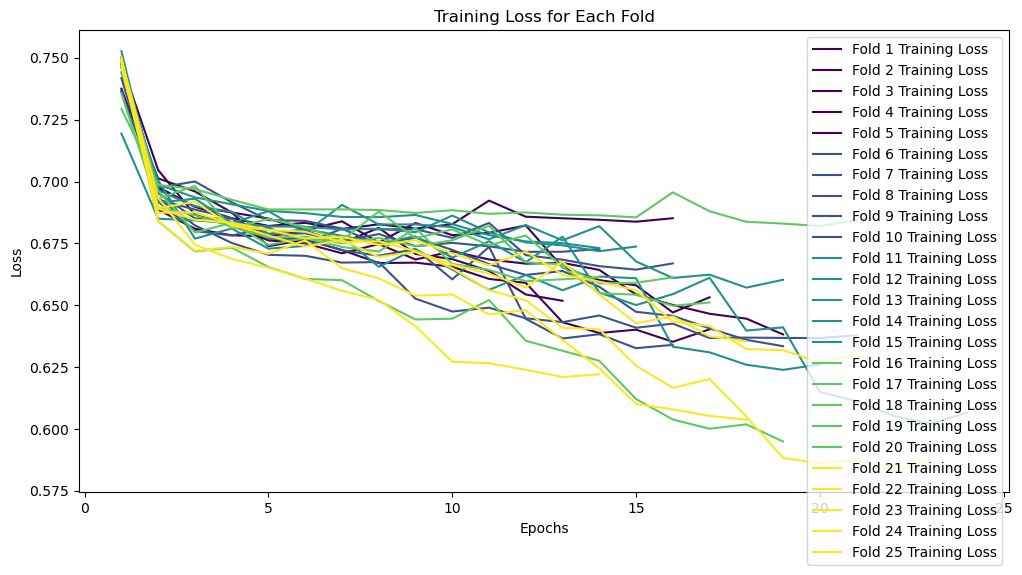

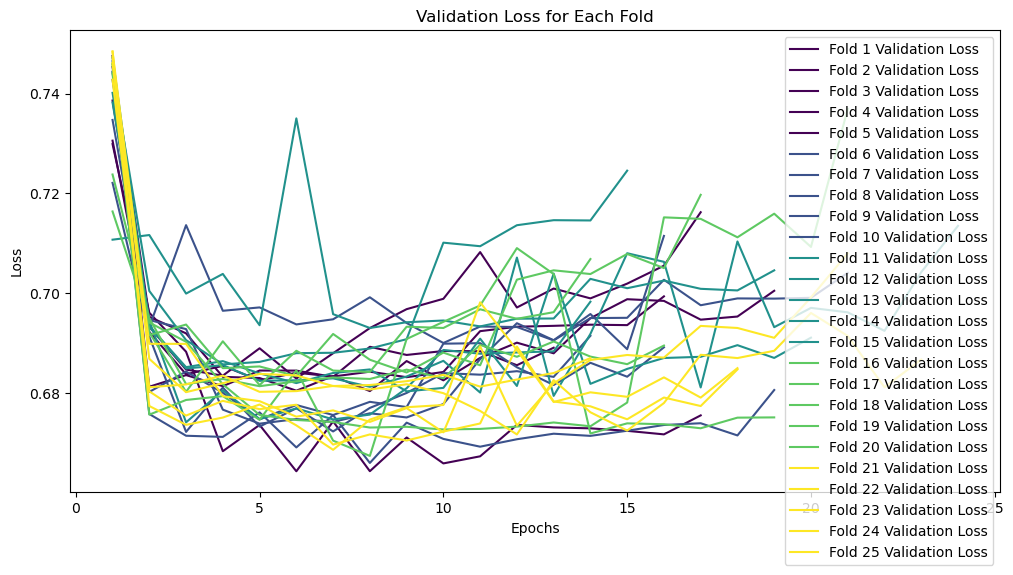

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm


plt.figure(figsize=(12, 6))
colors = cm.viridis(np.linspace(0, 1, 5))
for i, train_loss in enumerate(train_loss_list):
    plt.plot(
        range(1, len(train_loss) + 1),
        train_loss,
        label=f"Fold {i+1} Training Loss",
        color=colors[i // 5],
    )
plt.title("Training Loss for Each Fold")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("result/transformer_tabpfn_train_loss.svg")
plt.show()

# Plot the validation loss for each fold
plt.figure(figsize=(12, 6))
for i, val_loss in enumerate(val_loss_list):
    plt.plot(
        range(1, len(val_loss) + 1),
        val_loss,
        label=f"Fold {i+1} Validation Loss",
        color=colors[i // 5],
    )
plt.title("Validation Loss for Each Fold")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig("result/transformer_tabpfn_val_loss.svg")
plt.show()